In [1]:
#!pip install tensorflow

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Teen_Mental_Health_Augmented.csv")
#df = pd.read_csv("/Balanced_Teen_Mental_Health.csv")

df.columns = df.columns.str.strip()

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

print(df.head())
print(df.info())
print(df.isna().sum())
print(df['depression_label'].value_counts())

   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   17    male                       6.6      instagram          5.4   
1   15    male                       5.8      instagram          8.5   
2   17    male                       4.3           both          6.9   
3   15  female                       1.2      instagram          5.2   
4   17  female                       7.0         tiktok          4.7   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  2.51                0.9   
1                       1.3                  2.57                0.9   
2                       1.6                  3.28                0.8   
3                       1.0                  2.78                1.3   
4                       2.7                  2.74                0.2   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low            10              7   

In [5]:
df['gender']=df['gender'].map({'male':0,'female':1})


In [6]:
target_col = "depression_label"

X = df.drop(target_col, axis=1)
y = df[target_col]

X = pd.get_dummies(X, drop_first=True)
X = X.fillna(0)

print("Object columns:", X.select_dtypes(include='object').columns.tolist())
print("NaN in X:", X.isna().sum().sum())
print("NaN in y:", y.isna().sum())

Object columns: []
NaN in X: 0
NaN in y: 0


In [7]:
feature_columns = X.columns.tolist()

print(len(feature_columns))
print(feature_columns)

14
['age', 'gender', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'platform_usage_instagram', 'platform_usage_tiktok', 'social_interaction_level_low', 'social_interaction_level_medium']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(y_train.value_counts())
print(y_test.value_counts())

depression_label
1    2800
0    2800
Name: count, dtype: int64
depression_label
0    700
1    700
Name: count, dtype: int64


In [9]:
scaler = StandardScaler()

X_train_K = scaler.fit_transform(X_train).astype(np.float32)
X_test_K = scaler.transform(X_test).astype(np.float32)

y_train_K = y_train.astype(np.float32).values
y_test_K = y_test.astype(np.float32).values

print("NaN in X_train_K:", np.isnan(X_train_K).sum())
print("NaN in X_test_K:", np.isnan(X_test_K).sum())
print("NaN in y_train_K:", np.isnan(y_train_K).sum())
print("NaN in y_test_K:", np.isnan(y_test_K).sum())

NaN in X_train_K: 0
NaN in X_test_K: 0
NaN in y_train_K: 0
NaN in y_test_K: 0


In [10]:
model_keras = keras.Sequential([
    layers.Input(shape=(X_train_K.shape[1],)),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
])

model_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

model_keras.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model_keras.fit(
    X_train_K,
    y_train_K,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9252 - auc: 0.9809 - loss: 0.2480 - val_accuracy: 0.9848 - val_auc: 0.9991 - val_loss: 0.0489
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9886 - auc: 0.9987 - loss: 0.0449 - val_accuracy: 0.9884 - val_auc: 0.9994 - val_loss: 0.0330
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9908 - auc: 0.9989 - loss: 0.0323 - val_accuracy: 0.9866 - val_auc: 0.9995 - val_loss: 0.0296
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9902 - auc: 0.9990 - loss: 0.0288 - val_accuracy: 0.9884 - val_auc: 0.9995 - val_loss: 0.0358
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9926 - auc: 0.9990 - loss: 0.0251 - val_accuracy: 0.9866 - val_auc: 0.9996 - val_loss: 0.0291
Epoch 6/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9931 - auc: 0.9991 - loss: 0.0243 - val_accuracy: 0.9893 - val_auc: 0.9996 - val_loss: 0.0267
Epoch 7/100
140/140 ━━━━━━━━━━━━━━

In [12]:
y_prob = model_keras.predict(X_test_K).ravel()

print("NaN in y_prob:", np.isnan(y_prob).sum())
print("Min probability:", np.nanmin(y_prob))
print("Max probability:", np.nanmax(y_prob))

y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test_K, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test_K, y_prob))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
NaN in y_prob: 0
Min probability: 8.658209e-16
Max probability: 1.0
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       700
         1.0       0.99      0.99      0.99       700

    accuracy                           0.99      1400
   macro avg       0.99      0.99      0.99      1400
weighted avg       0.99      0.99      0.99      1400

ROC-AUC: 0.9998612244897959


**After using the balanced dataset, the neural network achieved significantly better performance on both classes. The recall for class 1 improved from a very low value to 0.98, showing that balancing the dataset helped the model detect minority-class cases more effectively.**

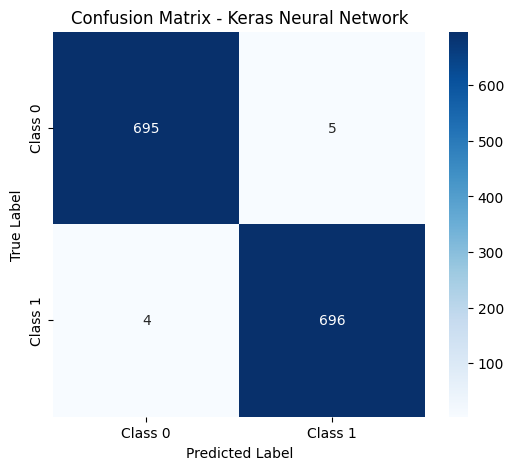

In [13]:
cm = confusion_matrix(y_test_K, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label',)
plt.title('Confusion Matrix - Keras Neural Network')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

**The confusion matrix shows that the model correctly classified most samples from both classes.**

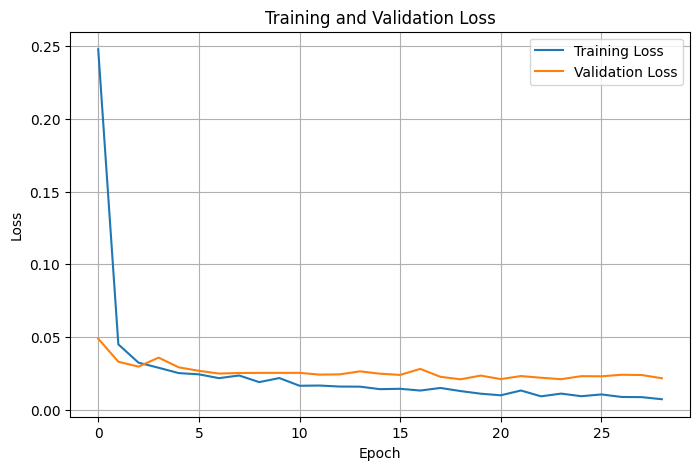

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.savefig('loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

**The training and validation curves show stable learning behavior**

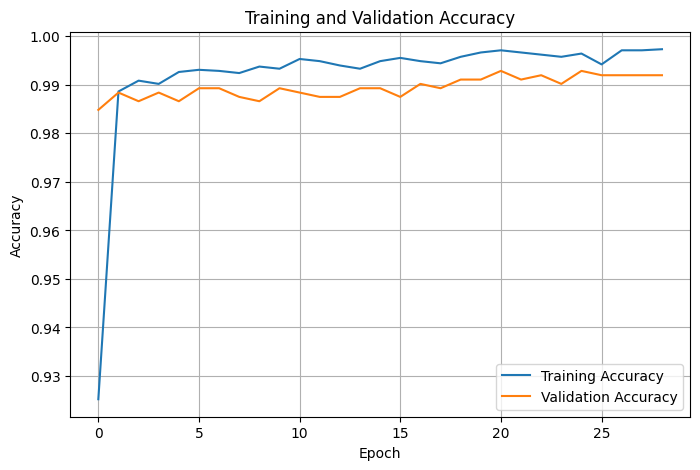

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.savefig('accuracy_curve.png', dpi=300, bbox_inches='tight')
plt.show()

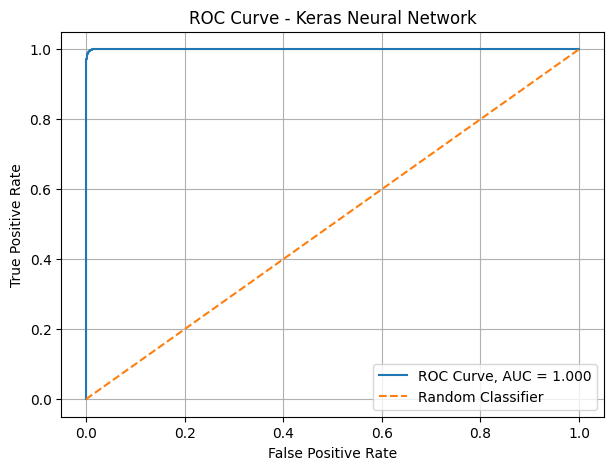

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test_K, y_prob)
auc_score = roc_auc_score(y_test_K, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f'ROC Curve, AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Keras Neural Network')
plt.legend()
plt.grid(True)

plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

**the ROC curve confirms strong classification performance with an AUC close to 1.0.**

In [17]:
import joblib
model_keras.save("teen_mental_health_model.keras")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

In [18]:
print("Number of features:", len(feature_columns))
print(feature_columns)

Number of features: 14
['age', 'gender', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'platform_usage_instagram', 'platform_usage_tiktok', 'social_interaction_level_low', 'social_interaction_level_medium']


In [19]:
test_probs = model_keras.predict(X_test_K[:20], verbose=0).ravel()

print(test_probs)
print((test_probs >= 0.5).astype(int))
print(y_test_K[:20])

[1.1782270e-08 9.9977916e-01 2.7180017e-06 3.3561048e-07 9.9999952e-01
 9.9992377e-01 9.9865764e-01 7.1727754e-08 2.1595339e-05 1.4784411e-04
 1.0000000e+00 9.3848321e-05 1.0000000e+00 9.9999982e-01 1.4717546e-08
 9.9999660e-01 5.1734729e-05 2.8173521e-04 9.9999994e-01 3.3576805e-05]
[0 1 0 0 1 1 1 0 0 0 1 0 1 1 0 1 0 0 1 0]
[0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 1. 0.]


In [20]:
!pip install gradio -q


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import gradio as gr
import pandas as pd
import numpy as np

print("Feature columns:", len(feature_columns))
print(feature_columns)
print("Scaler expects:", scaler.n_features_in_)
print("Model input shape:", model_keras.input_shape)


def predict_depression(
    age,
    gender,
    daily_social_media_hours,
    sleep_hours,
    screen_time_before_sleep,
    academic_performance,
    physical_activity,
    stress_level,
    anxiety_level,
    addiction_level,
    platform_usage,
    social_interaction_level
):
    # Build exactly same 14 training features
    row = {col: 0.0 for col in feature_columns}

    # Numeric features
    numeric_values = {
        "age": age,
        "daily_social_media_hours": daily_social_media_hours,
        "sleep_hours": sleep_hours,
        "screen_time_before_sleep": screen_time_before_sleep,
        "academic_performance": academic_performance,
        "physical_activity": physical_activity,
        "stress_level": stress_level,
        "anxiety_level": anxiety_level,
        "addiction_level": addiction_level
    }

    for col, value in numeric_values.items():
        if col in row:
            row[col] = float(value)

    # Gender encoding
    gender = str(gender).strip().lower()

    if "gender" in row:
        if gender == "male":
            row["gender"] = 0.0
        elif gender == "female":
            row["gender"] = 1.0
        else:
            row["gender"] = 2.0

    # Platform usage one-hot encoding
    # baseline: both = 0,0
    platform_usage = str(platform_usage).strip().lower()

    for col in feature_columns:
        if col.lower() in ["platform_usage_instagram", "platform_usage_tiktok"]:
            row[col] = 0.0

    if platform_usage == "instagram":
        for col in feature_columns:
            if col.lower() == "platform_usage_instagram":
                row[col] = 1.0

    elif platform_usage == "tiktok":
        for col in feature_columns:
            if col.lower() == "platform_usage_tiktok":
                row[col] = 1.0

    # if platform_usage == both, both columns remain 0

    # Social interaction one-hot encoding
    # baseline: high = 0,0
    social_interaction_level = str(social_interaction_level).strip().lower()

    for col in feature_columns:
        if col.lower() in ["social_interaction_level_low", "social_interaction_level_medium"]:
            row[col] = 0.0

    if social_interaction_level == "low":
        for col in feature_columns:
            if col.lower() == "social_interaction_level_low":
                row[col] = 1.0

    elif social_interaction_level == "medium":
        for col in feature_columns:
            if col.lower() == "social_interaction_level_medium":
                row[col] = 1.0

    # if social_interaction_level == high, both columns remain 0

    input_df = pd.DataFrame([row])
    input_df = input_df.reindex(columns=feature_columns, fill_value=0)
    input_df = input_df.astype(float)

    input_scaled = scaler.transform(input_df).astype(np.float32)

    probability = float(model_keras.predict(input_scaled, verbose=0)[0][0])
    prediction = int(probability >= 0.5)

    if prediction == 1:
        result = "High Depression Risk"
    else:
        result = "Low Depression Risk"

    debug = f"""
Encoded input:
{input_df.to_string(index=False)}

Scaled shape: {input_scaled.shape}
Probability: {probability}
Prediction: {prediction}
"""

    return result, round(probability, 6), debug

d:\AAUP\projects\AI research\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Feature columns: 14
['age', 'gender', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'platform_usage_instagram', 'platform_usage_tiktok', 'social_interaction_level_low', 'social_interaction_level_medium']
Scaler expects: 14
Model input shape: (None, 14)


In [22]:
print("Feature columns:", len(feature_columns))
print(feature_columns)

print("Scaler expects:", scaler.n_features_in_)
print("Model input shape:", model_keras.input_shape)

Feature columns: 14
['age', 'gender', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'platform_usage_instagram', 'platform_usage_tiktok', 'social_interaction_level_low', 'social_interaction_level_medium']
Scaler expects: 14
Model input shape: (None, 14)


In [23]:
interface = gr.Interface(
    fn=predict_depression,
    inputs=[
        gr.Number(label="Age", value=16,minimum=13,maximum=19),
        gr.Dropdown(["male", "female"], label="Gender", value="female"),
        gr.Number(label="Daily Social Media Hours", value=10),
        gr.Number(label="Sleep Hours", value=3),
        gr.Number(label="Screen Time Before Sleep", value=5),
gr.Slider(0, 5, step=0.1, label="Academic Performance", value=3.18) ,
        gr.Number(label="Physical Activity", value=0),
        gr.Slider(1, 10, step=1, label="Stress Level", value=10),
        gr.Slider(1, 10, step=1, label="Anxiety Level", value=10),
        gr.Slider(1, 10, step=1, label="Addiction Level", value=10),
        gr.Dropdown(["both", "instagram", "tiktok"], label="Platform Usage", value="tiktok"),
        gr.Dropdown(["high", "medium", "low"], label="Social Interaction Level", value="low")
    ],
    outputs=[
        gr.Textbox(label="Prediction Result"),
        gr.Number(label="Predicted Probability"),
        gr.Textbox(label="Debug Information", lines=10)
    ],
    title="Teen Mental Health Prediction System",
    description="This interface uses a trained Keras Neural Network model to predict depression risk. Educational use only."
)

interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://25021816e964c77ceb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [24]:
# Find a real sample from test set where the actual class is 1
idx = np.where(y_test_K == 1)[0][0]

real_input = X_test.iloc[idx]
real_scaled = X_test_K[idx].reshape(1, -1)

prob = model_keras.predict(real_scaled, verbose=0)[0][0]

print("Index:", idx)
print("Actual class:", y_test_K[idx])
print("Prediction probability:", prob)
print("Predicted class:", int(prob >= 0.5))
print(real_input)

Index: 1
Actual class: 1.0
Prediction probability: 0.99977916
Predicted class: 1
age                                   15
gender                                 0
daily_social_media_hours             7.7
sleep_hours                          6.1
screen_time_before_sleep             2.7
academic_performance                 2.4
physical_activity                    0.7
stress_level                           8
anxiety_level                          7
addiction_level                        9
platform_usage_instagram           False
platform_usage_tiktok              False
social_interaction_level_low        True
social_interaction_level_medium    False
Name: 4670, dtype: object
